# Imports

In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm import tqdm
from gc import collect
import timm


In [2]:
"""from google.colab import drive
drive.mount('/content/drive')"""


"from google.colab import drive\ndrive.mount('/content/drive')"

#Globals

In [2]:
"""train_path = "/content/drive/MyDrive/CVProject/dffd_small/train/"
test_path = "/content/drive/MyDrive/CVProject/dffd_small/test/"
validation_path = "/content/drive/MyDrive/CVProject/dffd_small/validation/"
"""
train_path = "./dffd_small/train/"
test_path = "./dffd_small/test/"
validation_path = "./dffd_small/validation/"
unseen_path = "./dffd_small/unseen/"

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
batch_size = 32
loss_ce = nn.CrossEntropyLoss()
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Utils

Utils for fsgm attack

In [5]:
def fgsm_attack(images, epsilon, grad, mean, std):
    # 1. Denormalizza le immagini
    mean = torch.tensor(mean).view(1, -1, 1, 1).to(images.device)
    std = torch.tensor(std).view(1, -1, 1, 1).to(images.device)
    images_denorm = images * std + mean

    # 2. Applica FGSM nel dominio reale [0,1]
    perturbed = images_denorm + epsilon * grad.sign()
    perturbed = torch.clamp(perturbed, 0, 1)

    # 3. Rinormalizza per il modello
    perturbed_norm = (perturbed - mean) / std
    return perturbed_norm

def denormalize(tensor, mean, std, device="cpu"):

    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)
    return tensor * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

def pgd_attack(model, images, labels, epsilon, alpha, steps):
    adv_images = images.clone().detach()
    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = F.cross_entropy(outputs, labels)
        grad = torch.autograd.grad(loss, adv_images)[0]
        adv_images = adv_images + alpha * grad.sign()  # Update
        # Project back to ε-ball (no clamping to [0,1] yet)
        delta = adv_images - images
        delta = torch.clamp(delta, -epsilon, epsilon)
        adv_images = (images + delta).detach()
    return adv_images

def normalize_batch(batch):
    transform = transforms.Normalize(mean=MEAN, std=STD)
    return torch.stack([transform(img) for img in batch])

def clamp_normed(tensor, mean, std):
    mean = torch.tensor(mean).view(1, -1, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(1, -1, 1, 1).to(tensor.device)
    # Calculate min and max normalized pixel values corresponding to [0,1] raw
    min_val = (0 - mean) / std
    max_val = (1 - mean) / std
    return torch.max(torch.min(tensor, max_val), min_val)

In [6]:
def evaluate_fgsm(model, dataloader, device, epsilon=0.01, visualize=False, num_visualize=5):
    model.eval()
    model.to(device)

    correct_adv = 0
    total_samples = 0

    all_labels = []
    all_preds_adv = []

    for batch in tqdm(dataloader):
        images, labels = batch["image"].to(device), batch["label"].to(device)
        images.requires_grad = True

        model.zero_grad()
        # Forward pass on clean images
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        # Zero grad and backward pass

        loss.backward()

        # Get gradients
        image_grad = images.grad.data

        adv_images = fgsm_attack(images, epsilon, image_grad, MEAN, STD, )

        # Forward pass on adversarial examples
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Accuracy
        correct_adv += (adv_preds == labels).sum().item()
        total_samples += labels.size(0)

        # Save predictions and labels for reporting
        all_labels.extend(labels.cpu().numpy())
        all_preds_adv.extend(adv_preds.cpu().numpy())

        if visualize and num_visualize > 0:
            adv_visual = denormalize(adv_images, MEAN, STD, device).detach()
            images_visual = denormalize(images, MEAN, STD, device).detach()
            for i in range(min(num_visualize, images.size(0))):
                plt.figure(figsize=(10, 3))

                orig = images_visual[i].detach().cpu().permute(1, 2, 0).numpy()
                adv = adv_visual[i].detach().cpu().permute(1, 2, 0).numpy()
                diff = np.clip((adv - orig) * 10, 0, 1)

                plt.subplot(1, 3, 1)
                plt.title(f"Original: {labels[i].item()}")
                plt.imshow(orig.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title(f"Adv (ε={epsilon})")
                plt.imshow(adv.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Difference")
                plt.imshow(diff)
                plt.axis('off')

                plt.show()

                num_visualize -= 1
                if num_visualize == 0:
                    break

    accuracy_adv = 100.0 * correct_adv / total_samples if total_samples > 0 else 0.0

    print(f"\nClassification Report on Adversarial Data (epsilon = {epsilon}):")
    print(classification_report(all_labels, all_preds_adv, digits=4))

    print("\nConfusion Matrix on Adversarial Data:")
    print(confusion_matrix(all_labels, all_preds_adv))

    return accuracy_adv


Utils for regularization

# Data

Color Augmentation might be beneficial against adversarial attacks. <br>
Without ColorJitter() -> 95% accuracy, 2% accuracy FGSM 0.001 epsilon <br>
With ColorJitter() -> 90% accuracy, 6% accyract FGSN 0.001 epsilon

In [8]:

train_img_augm = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_img_augm = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [9]:

class RealFakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        # Expecting subfolders 'real/' and 'fake/' inside root_dir
        for label_str, label in [("real", 0), ("fake", 1)]:
            folder = Path(root_dir) / label_str
            if not folder.exists():
                continue
            for file in folder.glob("*.png"):
                self.samples.append((file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


    def collate_fn(self, batch):
        images, labels = zip(*batch)  # unzip list of tuples
        images = torch.stack(images)  # stack image tensors into a single batch tensor
        labels = torch.tensor(labels) # convert labels to a tensor
        return {"image": images, "label":labels }




In [10]:
train_dataset = RealFakeDataset(train_path, transform=train_img_augm)
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=train_dataset.collate_fn,num_workers=8)

test_dataset = RealFakeDataset(test_path, test_img_augm)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=True, collate_fn=test_dataset.collate_fn,num_workers=8)

validation_dataset = RealFakeDataset(validation_path, transform=test_img_augm)
validation_dataloader = DataLoader(validation_dataset, batch_size, shuffle=True, collate_fn=validation_dataset.collate_fn,num_workers=8)

unseen_dataset = RealFakeDataset(unseen_path, transform=test_img_augm)
unseen_dataloader = DataLoader(unseen_dataset, batch_size, shuffle=True, collate_fn=unseen_dataset.collate_fn,num_workers=8)


Creation of augmented dataset for training of both distorted image and normal

In [11]:
class AdversarialDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, model, mean, std, epsilon_range=(0.01, 0.03), 
                 distribution="log_normal", adv_prob=0.5, device='cuda'):
        self.dataset = base_dataset
        self.model = model.eval()
        self.mean = mean
        self.std = std
        self.epsilon_range = epsilon_range
        self.distribution = distribution
        self.adv_prob = adv_prob
        self.device = device

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, label = self.dataset[idx]
        image = image.to(self.device)
        label = torch.tensor(label).to(self.device)

        if torch.rand(1).item() < self.adv_prob:
            # Generate adversarial example
            image = image.unsqueeze(0)
            image.requires_grad = True
            output = self.model(image)
            loss = F.cross_entropy(output, label.unsqueeze(0))
            self.model.zero_grad()
            loss.backward()

            grad = image.grad.data
            epsilon = self.sample_epsilon().to(self.device)
            image = fgsm_attack(image, epsilon, grad, self.mean, self.std)
            image = image.squeeze(0).detach()

        return image.cpu(), label.cpu()

    def sample_epsilon(self):
        if self.distribution == 'uniform':
            return torch.empty(1).uniform_(*self.epsilon_range)
        elif self.distribution == 'log_normal':
            log_min = torch.log(torch.tensor(self.epsilon_range[0]))
            log_max = torch.log(torch.tensor(self.epsilon_range[1]))
            return torch.exp(torch.empty(1).uniform_(log_min, log_max))
        else:
            raise ValueError("Invalid distribution")


In [12]:
def plot_accuracies(accuracies, epsilons):
    plt.figure(figsize=(8, 5))  # Increase size for clarity
    plt.plot(epsilons, accuracies, marker='o', linestyle='-', color='blue', label='Adversarial Accuracy')

    # Set fewer x-ticks for readability
    step = 0.01 if max(epsilons) > 0.05 else 0.005
    plt.xticks(np.arange(0, max(epsilons)+step, step), rotation=45)

    plt.yticks(np.arange(0, 110, step=10))

    plt.title("Model Accuracy vs FGSM Epsilon")
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
def train(model, train_loader, test_loader, optimizer, device, epochs=5):
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            images, labels = batch["image"].to(device), batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1} - Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

        # Evaluation phase
        model.eval()
        eval_loss = 0.0
        eval_correct = 0
        eval_total = 0

        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} - Evaluating"):
                images, labels = batch["image"].to(device), batch["label"].to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                eval_loss += loss.item()

                preds = outputs.argmax(dim=1)
                eval_correct += (preds == labels).sum().item()
                eval_total += labels.size(0)

        eval_loss /= len(test_loader)
        eval_acc = 100 * eval_correct / eval_total
        print(f"Epoch {epoch+1} - Eval Loss: {eval_loss:.4f} | Eval Acc: {eval_acc:.2f}%\n")


# Network

In [14]:
normal_model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
robust_model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

In [15]:
class ShallowModel(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.shallow1 = model.conv_stem
        self.shallow2 = model.bn1
        self.shallow3 = model.blocks[0]
        self.shallow4 = model.blocks[1]
        self.shallow5 = model.blocks[2]

    def forward(self, x):
        x = self.shallow1(x)
        x = self.shallow2(x)

        x = self.shallow3(x)

        x = self.shallow4(x)

        x = self.shallow5(x)

        return x


In [16]:
class DeepModel(nn.Module):
    def __init__(self, model):
        super().__init__()

        self.blocks = model.blocks[3:]
        self.conv_head = model.conv_head
        self.bn2 = model.bn2
        self.global_pool = model.global_pool
        self.classifier = model.classifier

    def forward(self, input):

        x = self.blocks(input)
        x = self.conv_head(x)
        x = self.bn2(x)
        x = self.global_pool(x)
        x = self.classifier(x)

        return x

In [17]:
class EfficientNet(nn.Module):

    def __init__(self, model):
        super().__init__()

        self.shallow = ShallowModel(model)
        self.deep = DeepModel(model)

    def forward(self, input):

        x = self.shallow(input)
        x = self.deep(x)

        return x

# Train

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].


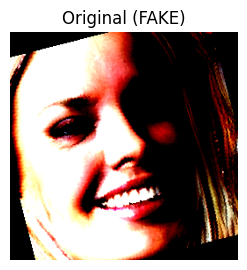

In [16]:
for i, elem in enumerate(train_dataloader):
    if(i==1):
        break

    with torch.no_grad():
        orig_img = elem["image"][0]
        orig_img = orig_img.permute(1,2,0).squeeze(0)
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1)
        target = "FAKE" if elem["label"][0] == 1 else "REAL"
        plt.title(f"Original ({target})")
        plt.imshow(orig_img)
        plt.axis("off")


In [28]:
# Freeze all parameters
for param in normal_model.parameters():
    param.requires_grad = True

"""# Unfreeze selected final layers
for layer_name in ['conv_head', 'bn2', 'global_pool', 'classifier']:
    layer = getattr(normal_model, layer_name)
    for param in layer.parameters():
        param.requires_grad = True"""


for param in robust_model.parameters():
    param.requires_grad = True

In [23]:
optimizer = torch.optim.Adam(normal_model.parameters(), 0.0001, weight_decay=0.0001)
train(model=normal_model,
      train_loader=train_dataloader,
      test_loader = test_dataloader,
      optimizer=optimizer,
      device=device,
      epochs=1)

Epoch 1/1 - Training:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/1 - Training: 100%|██████████| 250/250 [00:22<00:00, 11.29it/s]


Epoch 1 - Train Loss: 0.4532 | Train Acc: 88.05%


Epoch 1/1 - Evaluating: 100%|██████████| 63/63 [00:01<00:00, 32.88it/s]

Epoch 1 - Eval Loss: 0.2717 | Eval Acc: 92.25%



Training the model with pmi defined on paper

In [18]:
def evaluate_model(model, test_dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            images, labels = batch["image"].to(device), batch["label"].to(device)
            logits = model.deep(model.shallow(images))  # adjust if not split
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(test_dataloader)
    f1 = f1_score(all_labels, all_preds, average="macro")  # or "weighted" or "micro" depending on your use case

    return avg_loss, accuracy, f1


In [29]:
def calculate_deltas(grad_mean, grad_sigma, r):

    grad_mean_norm = torch.sqrt((grad_mean ** 2).sum(dim=1, keepdim=True)) + 1e-8
    grad_std_norm = torch.sqrt((grad_sigma ** 2).sum(dim=1, keepdim=True)) + 1e-8

    dmu = r*grad_mean/grad_mean_norm
    dsigma = r*grad_sigma/grad_std_norm

    return dmu, dsigma

def calculate_f_prime(features, mu, sigma, dmu, dsigma):

        f_norm = (features - mu) / (sigma+1e-8)

        f_prime = f_norm*(sigma+dsigma) + (mu+dmu)

        return f_prime

# Training loop with PMI
def train_with_pmi(model, train_dataloader, eval_loader, optimizer, loss_ce, device, scheduler, num_epochs=5, alpha=0.1, r=0.1, patience = 5):
    model.to(device)
    
    counter = 0
    best_f1 = 0.0
    best_model = None

    for epoch in range(num_epochs):
        model.train()
        epoch_perturbed_loss = 0.0
        epoch_clean_loss = 0.0
        
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = batch["image"].to(device), batch["label"].to(device)


            optimizer.zero_grad()
            # First forward step
            shallow = model.shallow
            shallow_layers = [shallow.shallow1, shallow.shallow2, shallow.shallow3, shallow.shallow4, shallow.shallow5]

            dmus = [0 for i in range(len(shallow_layers))]
            dsigmas = [0 for i in range(len(shallow_layers))]

            means = [0 for i in range(len(shallow_layers))]
            stds = [0 for i in range(len(shallow_layers))]

            f_primes = [0 for i in range(len(shallow_layers))]


            for i, layer in enumerate(shallow_layers):
                if i == 0:
                    # normal forward for first shallow layer on input images
                    feature = layer(images)
                else:
                    # feed perturbed feature from previous layer for subsequent shallow layers
                    feature = layer(f_primes[i-1])

                # Calculate Means and Stds
                means[i] = torch.mean(feature, [2,3], keepdim=True)
                means[i].retain_grad()

                stds[i] = torch.std(feature, [2,3], keepdim=True)
                stds[i].retain_grad()

                f_primes[i] = calculate_f_prime(feature, means[i], stds[i], dmus[i], dsigmas[i])
                f_primes[i].retain_grad()

            deep = model.deep
            logits = deep(f_primes[-1])

            loss = loss_ce(logits, labels)
            epoch_clean_loss+=loss.item()

            loss.backward(retain_graph=True)
            # At this point we should have access to gradient wrt mu and sigma
            grads_g1 = [p.grad.clone() for p in shallow.parameters()]

            optimizer.zero_grad()
            for i in range(len(shallow_layers)):
                dmu, dsigma = calculate_deltas(means[i].grad, stds[i].grad, r)
                dmus[i] = dmu.detach()
                dsigmas[i] = dsigma.detach()



            for i, layer in enumerate(shallow_layers):
                f_primes[i] = calculate_f_prime(f_primes[i].detach(), means[i], stds[i], dmus[i], dsigmas[i])


            logits_perturbed = deep(f_primes[-1])

            # Losses
            loss_perturbed = loss_ce(logits_perturbed, labels)
            epoch_perturbed_loss+=loss_perturbed.item()
            loss_perturbed.backward()

            grads_g2 = [p.grad.clone() for p in shallow.parameters()]
            
            loss_clean = loss
            
            for p, g1, g2 in zip(shallow.parameters(), grads_g1, grads_g2):
                p.grad = (1 - alpha) * g1 + alpha * g2

            optimizer.step()
            del loss, loss_clean, loss_perturbed, logits, logits_perturbed


        avg_perturbed_loss = epoch_perturbed_loss / len(train_dataloader)
        avg_clean_loss = epoch_clean_loss / len(train_dataloader)
        test_loss, test_accuracy, test_f1 = evaluate_model(model, eval_loader, loss_ce, device)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Clean Loss: {avg_clean_loss:.4f} | "
            f"Train Perturbed Loss: {avg_perturbed_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Accuracy: {test_accuracy:.2f}% | "
            f"Test F1: {test_f1:.4f}"
        )
        if(test_f1>best_f1):
            best_model = model.state_dict()
            counter = 0
            best_f1 = test_f1 
        else:
            counter+=1
            if(counter>=patience):
                print("Early stopping triggered...")
                break

        
        scheduler.step(test_f1)

    return model.load_state_dict(best_model)

# Test

Test and report for the base model

In [20]:
def report(model, test_loader, loss):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    import matplotlib.pyplot as plt
    model = model.to(device)
    model.eval()
    all_predictions = []
    all_targets = []

    total_loss = 0.0
    with torch.no_grad():
      for batch in tqdm(test_loader):
        input, target = batch["image"], batch["label"]

        input = input.to(device)
        target = target.to(device)

        output = model(input)

        l = loss(output, target)
        total_loss += l.item()

        # Get predictions
        preds = torch.argmax(output, dim=1)  # Adjust if it's binary or multilabel

        all_predictions.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions, digits=4))  # Adjust labels if needed

    # Plot confusion matrix
    label_names = ["REAL", "FAKE"]

    cm = confusion_matrix(all_targets, all_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

100%|██████████| 63/63 [00:01<00:00, 33.18it/s]



Classification Report:
              precision    recall  f1-score   support

           0     0.8991    0.9530    0.9252      1000
           1     0.9500    0.8930    0.9206      1000

    accuracy                         0.9230      2000
   macro avg     0.9245    0.9230    0.9229      2000
weighted avg     0.9245    0.9230    0.9229      2000



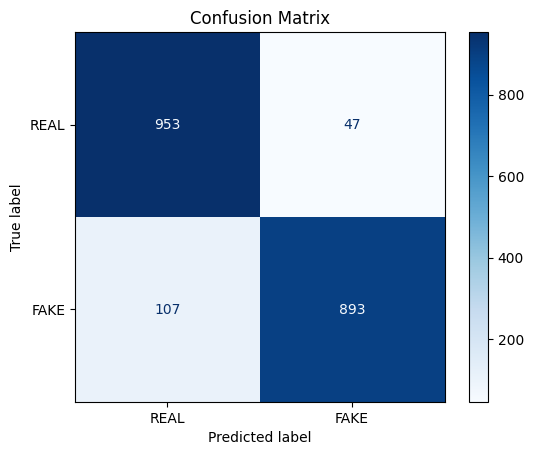

In [24]:
report(normal_model, validation_dataloader, loss_ce)


Evaluating with FGSM (epsilon = 0)


  0%|          | 0/63 [00:00<?, ?it/s]

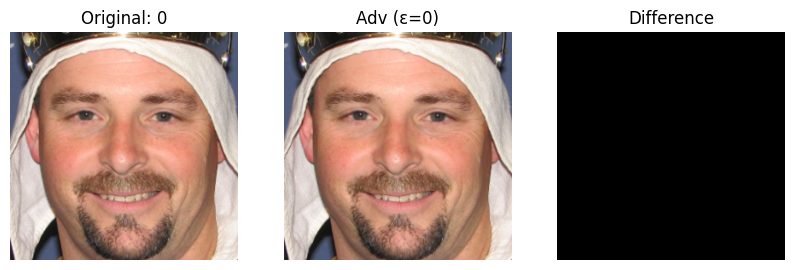

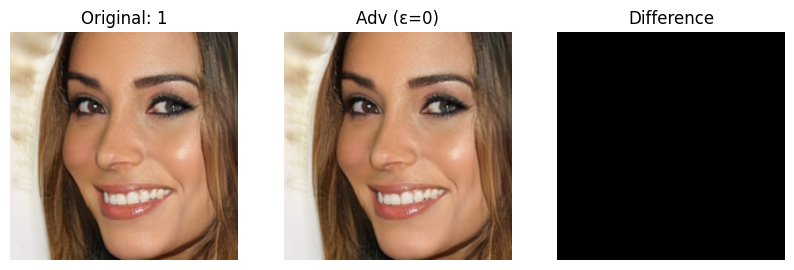

100%|██████████| 63/63 [00:07<00:00,  8.81it/s]



Classification Report on Adversarial Data (epsilon = 0):
              precision    recall  f1-score   support

           0     0.9116    0.9180    0.9148      1000
           1     0.9174    0.9110    0.9142      1000

    accuracy                         0.9145      2000
   macro avg     0.9145    0.9145    0.9145      2000
weighted avg     0.9145    0.9145    0.9145      2000


Confusion Matrix on Adversarial Data:
[[918  82]
 [ 89 911]]

Evaluating with FGSM (epsilon = 0.01)


  0%|          | 0/63 [00:00<?, ?it/s]

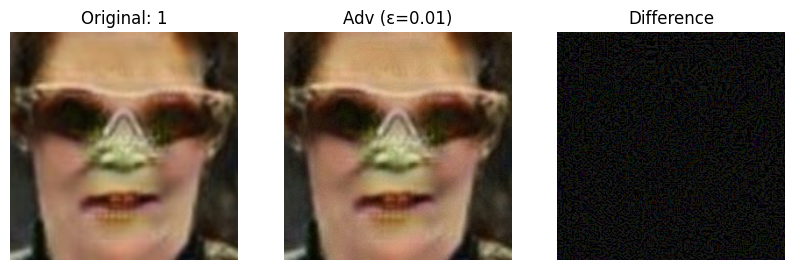

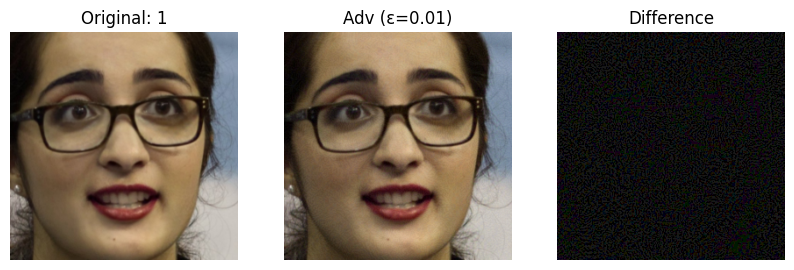

100%|██████████| 63/63 [00:07<00:00,  8.99it/s]



Classification Report on Adversarial Data (epsilon = 0.01):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0934    0.1030    0.0980      1000

    accuracy                         0.0515      2000
   macro avg     0.0467    0.0515    0.0490      2000
weighted avg     0.0467    0.0515    0.0490      2000


Confusion Matrix on Adversarial Data:
[[   0 1000]
 [ 897  103]]

Evaluating with FGSM (epsilon = 0.1)


  0%|          | 0/63 [00:00<?, ?it/s]

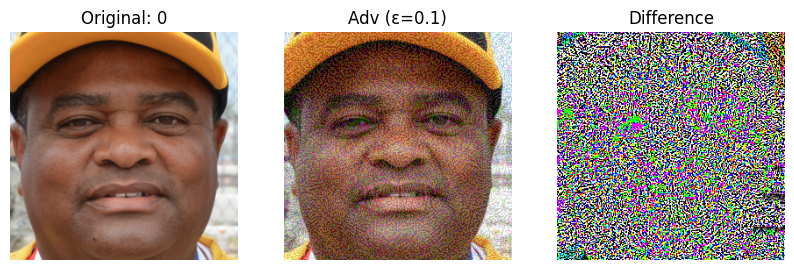

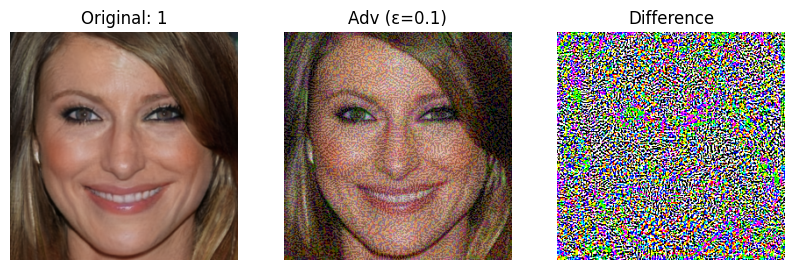

100%|██████████| 63/63 [00:06<00:00,  9.06it/s]



Classification Report on Adversarial Data (epsilon = 0.1):
              precision    recall  f1-score   support

           0     0.4214    0.3540    0.3848      1000
           1     0.4431    0.5140    0.4759      1000

    accuracy                         0.4340      2000
   macro avg     0.4323    0.4340    0.4304      2000
weighted avg     0.4323    0.4340    0.4304      2000


Confusion Matrix on Adversarial Data:
[[354 646]
 [486 514]]

Evaluating with FGSM (epsilon = 0.3)


  0%|          | 0/63 [00:00<?, ?it/s]

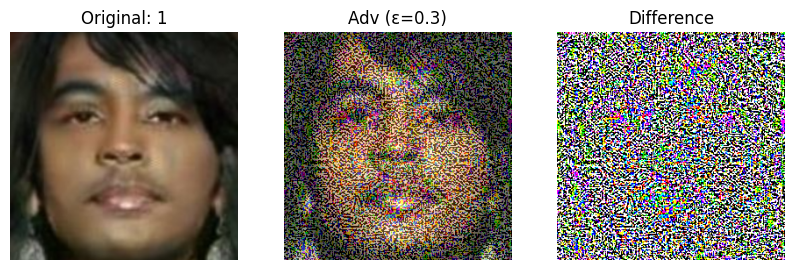

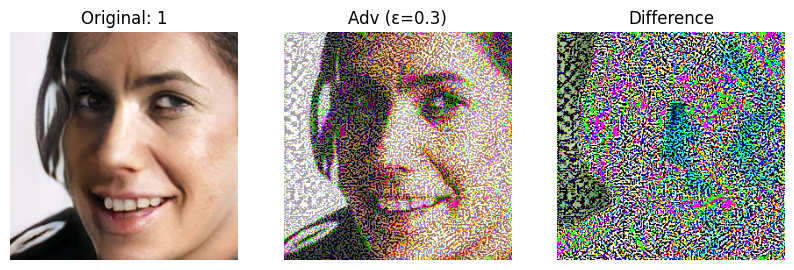

100%|██████████| 63/63 [00:07<00:00,  8.94it/s]


Classification Report on Adversarial Data (epsilon = 0.3):
              precision    recall  f1-score   support

           0     0.5576    0.4310    0.4862      1000
           1     0.5363    0.6580    0.5909      1000

    accuracy                         0.5445      2000
   macro avg     0.5469    0.5445    0.5386      2000
weighted avg     0.5469    0.5445    0.5386      2000


Confusion Matrix on Adversarial Data:
[[431 569]
 [342 658]]


In [30]:
epsilons = [0, 0.01, 0.1, 0.3]
accuracies = []

for eps in epsilons:
    print(f"\nEvaluating with FGSM (epsilon = {eps})")
    acc = evaluate_fgsm(
        model=normal_model,              # modello NON addestrato con FGSM
        dataloader=test_dataloader,          # dataloader dei dati CLEAN (non attaccati)
        device=device,
        epsilon=eps,
        visualize=True,                  # opzionale, disattiva se non ti serve
        num_visualize=2                  # quante immagini mostrare per epsilon
    )
    accuracies.append(acc)


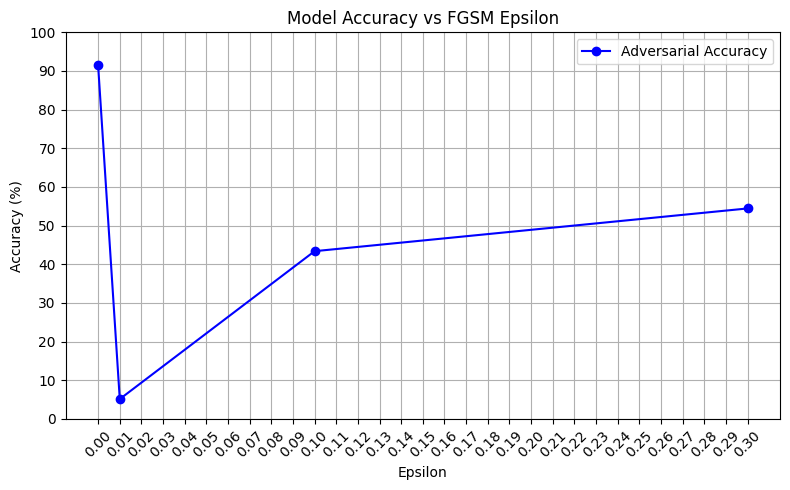

In [31]:
plot_accuracies(accuracies=accuracies, epsilons=epsilons)

Report and test for the base model applies to the augmented datatset

In [35]:
# Genera il dataset aumentato
augmented_dataset = AdversarialDataset(model=normal_model, base_dataset=train_dataset, device=device, adv_prob=0.5, mean=MEAN, std=STD, epsilon_range=(0.0001, 0.5), distribution="uniform")
augmented_dataloader = DataLoader(augmented_dataset, batch_size=32, shuffle=True, collate_fn=train_dataset.collate_fn)

In [26]:
for i,elem in enumerate(augmented_dataloader):
    if(i==1):
        break
    print(elem)

{'image': tensor([[[[-1.8555, -1.8555, -2.1179,  ..., -1.8555, -1.8555, -1.8555],
          [-2.1179, -2.1179, -2.1179,  ..., -1.8555, -1.8555, -1.8555],
          [-1.8555, -2.1179, -1.8555,  ..., -1.8555, -2.1179, -1.8555],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -1.8555, -1.8555, -1.8555],
          [-1.8555, -1.8555, -1.8555,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -1.8555, -1.8555]],

         [[-2.0357, -1.7674, -2.0357,  ..., -1.7674, -1.7674, -1.7674],
          [-2.0357, -2.0357, -2.0357,  ..., -1.7674, -1.7674, -1.7674],
          [-1.7674, -2.0357, -1.7674,  ..., -1.7674, -1.7674, -1.7674],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -1.7674, -1.7674, -1.7674],
          [-1.7674, -1.7674, -1.7674,  ..., -2.0357, -2.0357, -2.0357],
          [-1.7674, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -1.7674]],

         [[-1.5373, -1.5373, -1.8044,  ..., -1.8044, -1.5373, -1.5373],
          [-1.5373, 

In [37]:
optimizer = torch.optim.Adam(normal_model.parameters(), lr=1e-3)
train(model=normal_model, 
      train_loader=augmented_dataloader, 
      test_loader=validation_dataloader,
      optimizer=optimizer, 
      device=device, 
      epochs=2)


Epoch 1/2 - Training: 100%|██████████| 250/250 [01:18<00:00,  3.18it/s]


Epoch 1 - Train Loss: 0.9990 | Train Acc: 64.89%


Epoch 1/2 - Evaluating: 100%|██████████| 63/63 [00:01<00:00, 34.71it/s]


Epoch 1 - Eval Loss: 4375.7873 | Eval Acc: 54.75%



Epoch 2/2 - Training: 100%|██████████| 250/250 [01:15<00:00,  3.33it/s]


Epoch 2 - Train Loss: 0.4879 | Train Acc: 77.42%


Epoch 2/2 - Evaluating: 100%|██████████| 63/63 [00:01<00:00, 33.96it/s]

Epoch 2 - Eval Loss: 50355.0896 | Eval Acc: 48.15%



Testing with Fsgm attack


Evaluating with FGSM (epsilon = 0)


  0%|          | 0/63 [00:00<?, ?it/s]

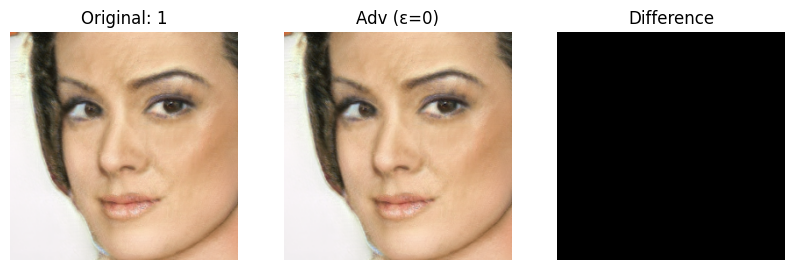

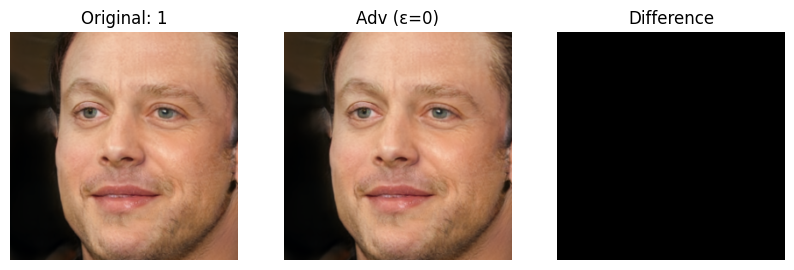

100%|██████████| 63/63 [00:06<00:00,  9.13it/s]



Classification Report on Adversarial Data (epsilon = 0):
              precision    recall  f1-score   support

           0     0.4870    0.9190    0.6366      1000
           1     0.2832    0.0320    0.0575      1000

    accuracy                         0.4755      2000
   macro avg     0.3851    0.4755    0.3471      2000
weighted avg     0.3851    0.4755    0.3471      2000


Confusion Matrix on Adversarial Data:
[[919  81]
 [968  32]]

Evaluating with FGSM (epsilon = 0.0001)


  0%|          | 0/63 [00:00<?, ?it/s]

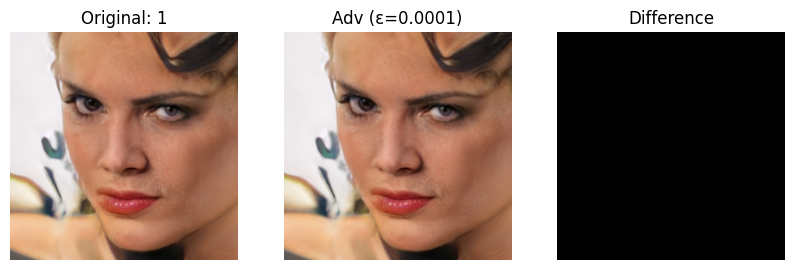

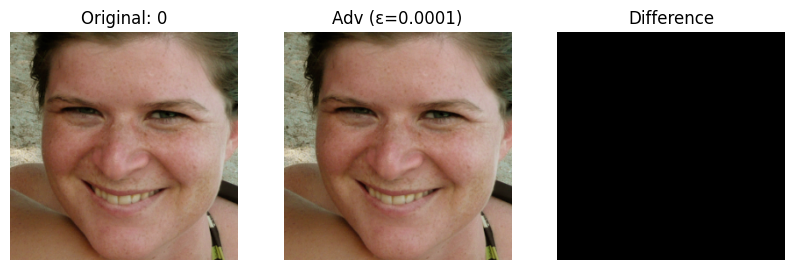

100%|██████████| 63/63 [00:07<00:00,  8.95it/s]



Classification Report on Adversarial Data (epsilon = 0.0001):
              precision    recall  f1-score   support

           0     0.4810    0.9090    0.6291      1000
           1     0.1727    0.0190    0.0342      1000

    accuracy                         0.4640      2000
   macro avg     0.3268    0.4640    0.3316      2000
weighted avg     0.3268    0.4640    0.3316      2000


Confusion Matrix on Adversarial Data:
[[909  91]
 [981  19]]

Evaluating with FGSM (epsilon = 0.001)


  0%|          | 0/63 [00:00<?, ?it/s]

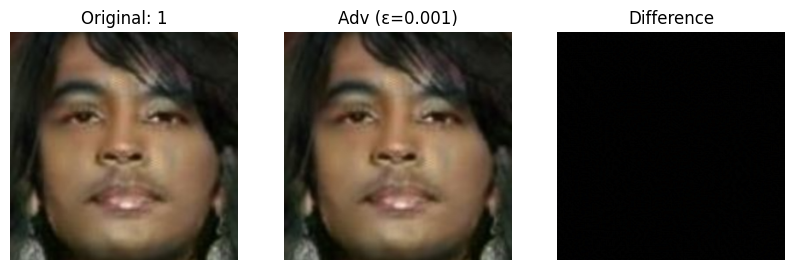

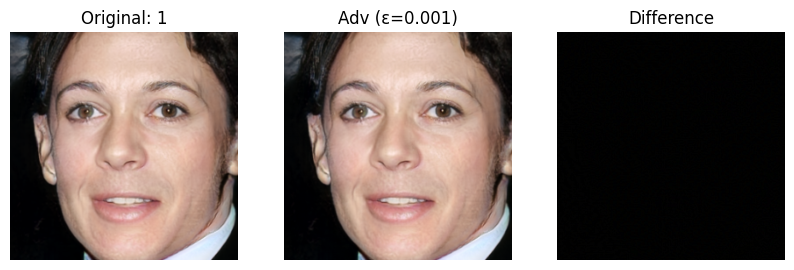

100%|██████████| 63/63 [00:07<00:00,  8.93it/s]



Classification Report on Adversarial Data (epsilon = 0.001):
              precision    recall  f1-score   support

           0     0.4824    0.9300    0.6352      1000
           1     0.0278    0.0020    0.0037      1000

    accuracy                         0.4660      2000
   macro avg     0.2551    0.4660    0.3195      2000
weighted avg     0.2551    0.4660    0.3195      2000


Confusion Matrix on Adversarial Data:
[[930  70]
 [998   2]]

Evaluating with FGSM (epsilon = 0.01)


  0%|          | 0/63 [00:00<?, ?it/s]

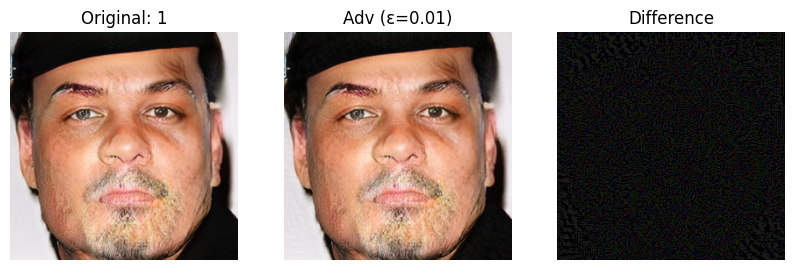

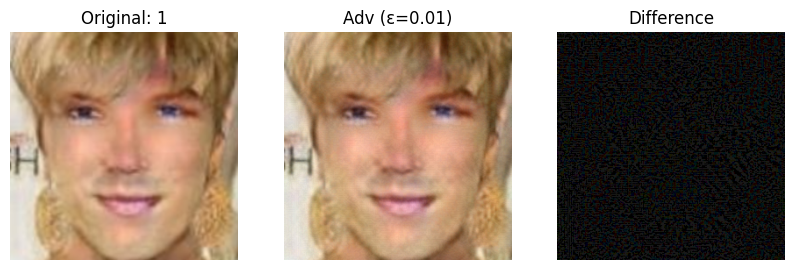

100%|██████████| 63/63 [00:07<00:00,  8.55it/s]



Classification Report on Adversarial Data (epsilon = 0.01):
              precision    recall  f1-score   support

           0     0.4785    0.9000    0.6248      1000
           1     0.1597    0.0190    0.0340      1000

    accuracy                         0.4595      2000
   macro avg     0.3191    0.4595    0.3294      2000
weighted avg     0.3191    0.4595    0.3294      2000


Confusion Matrix on Adversarial Data:
[[900 100]
 [981  19]]

Evaluating with FGSM (epsilon = 0.1)


  0%|          | 0/63 [00:00<?, ?it/s]

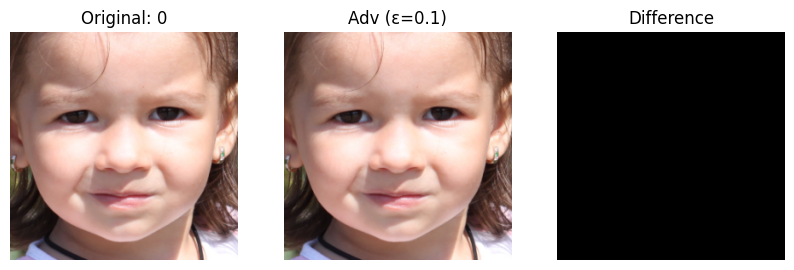

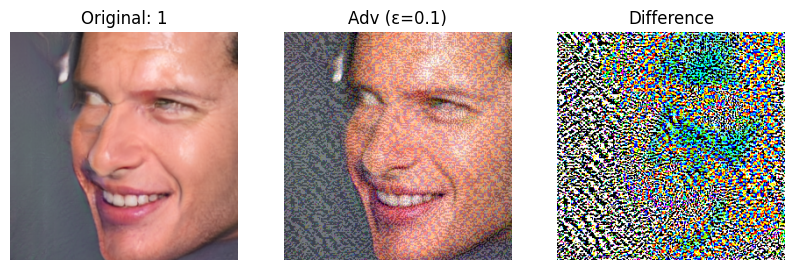

100%|██████████| 63/63 [00:07<00:00,  8.96it/s]



Classification Report on Adversarial Data (epsilon = 0.1):
              precision    recall  f1-score   support

           0     0.9962    0.7800    0.8749      1000
           1     0.8192    0.9970    0.8994      1000

    accuracy                         0.8885      2000
   macro avg     0.9077    0.8885    0.8872      2000
weighted avg     0.9077    0.8885    0.8872      2000


Confusion Matrix on Adversarial Data:
[[780 220]
 [  3 997]]


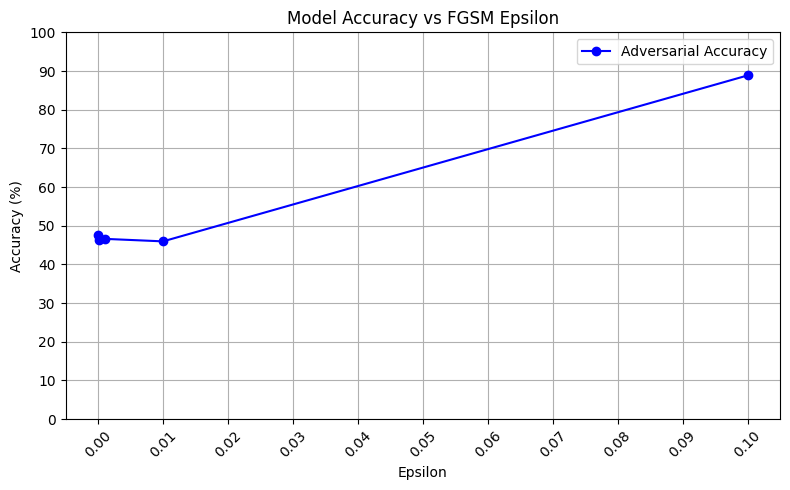

In [38]:
epsilons = [0, 0.0001, 0.001, 0.01, 0.1]
accuracies = []

for eps in epsilons:
    print(f"\nEvaluating with FGSM (epsilon = {eps})")
    acc = evaluate_fgsm(
        model=normal_model,              
        dataloader=test_dataloader,          
        device=device,
        epsilon=eps,
        visualize=True,                 
        num_visualize=2
    )
    accuracies.append(acc)

plot_accuracies(accuracies=accuracies, epsilons = epsilons)

Regularization implementation (from paper)

In [35]:
from gc import collect
torch.cuda.empty_cache()
collect()

20911

In [33]:
torch.cuda.empty_cache()
#del normal_model
#del eff_model
collect()

0

In [ ]:
eff_model = EfficientNet(robust_model)

# Example: Only unfreeze shallow layers
for param in eff_model.shallow.parameters():
    param.requires_grad = True

# Freeze deeper layers if desired
for param in eff_model.deep.parameters():
    param.requires_grad = False

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    eff_model.parameters(), 
    lr=0.001,  # Reduced from 0.01
    momentum=0.9, 
    weight_decay=1e-3
)
pmi_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

alpha = 0.1 # Weight to do to clean loss -> perturbed loss weight = 1-alpha
trained_model = train_with_pmi(model=eff_model,
                               train_dataloader=train_dataloader,
                               eval_loader=unseen_dataloader,
                               optimizer=optimizer,
                               loss_ce=loss,
                               device=device,
                               scheduler=pmi_scheduler,
                               num_epochs=10,
                               alpha=alpha,
                               r=0.05)

Epoch 1/10:   0%|          | 0/250 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 0 has a total capacity of 11.58 GiB of which 62.56 MiB is free. Including non-PyTorch memory, this process has 10.55 GiB memory in use. Of the allocated memory 10.14 GiB is allocated by PyTorch, and 186.34 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

100%|██████████| 63/63 [00:01<00:00, 33.54it/s]


Classification Report:
              precision    recall  f1-score   support

           0     0.5305    0.9650    0.6846      1000
           1     0.8066    0.1460    0.2472      1000

    accuracy                         0.5555      2000
   macro avg     0.6686    0.5555    0.4659      2000
weighted avg     0.6686    0.5555    0.4659      2000



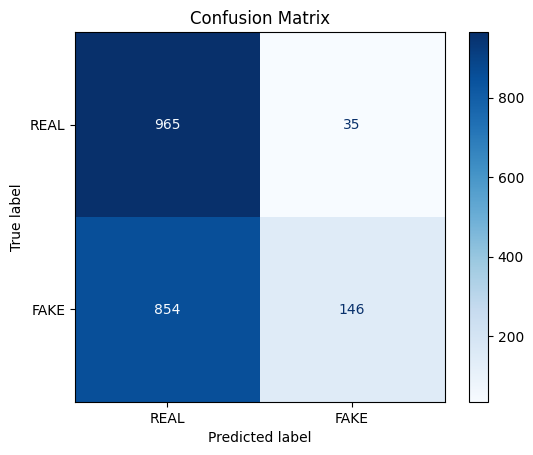

100%|██████████| 63/63 [00:01<00:00, 32.72it/s]



Classification Report:
              precision    recall  f1-score   support

           0     0.5097    0.9450    0.6622      1000
           1     0.6233    0.0910    0.1588      1000

    accuracy                         0.5180      2000
   macro avg     0.5665    0.5180    0.4105      2000
weighted avg     0.5665    0.5180    0.4105      2000



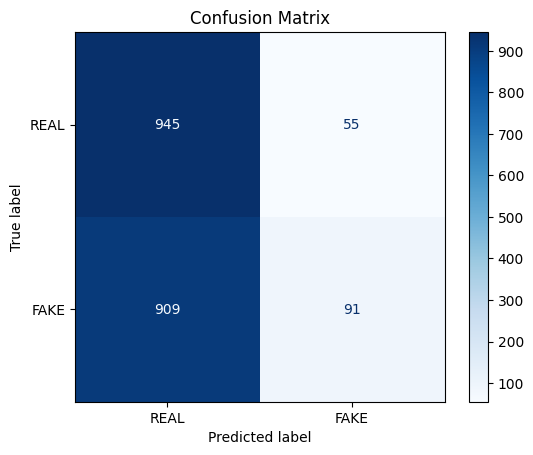

In [32]:
report(normal_model, unseen_dataloader, loss_ce)
report(robust_model, unseen_dataloader, loss_ce)


Evaluating with FGSM (epsilon = 0)


  0%|          | 0/63 [00:00<?, ?it/s]

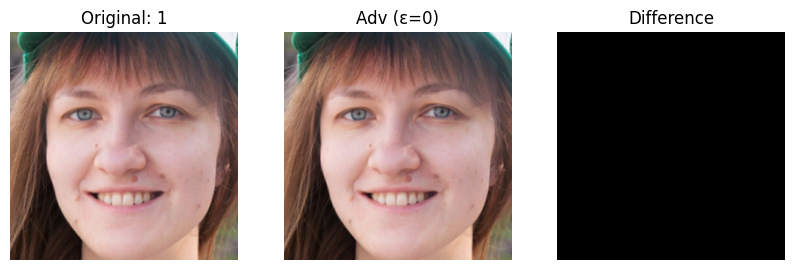

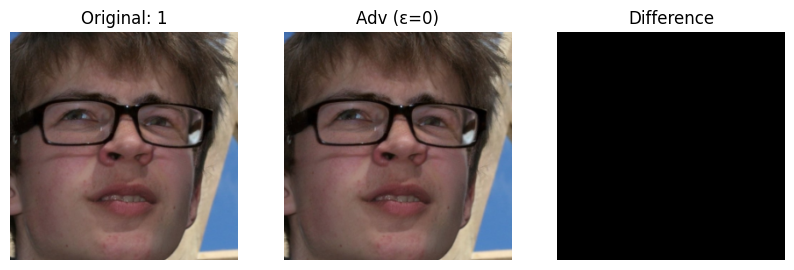

100%|██████████| 63/63 [00:06<00:00,  9.81it/s]



Classification Report on Adversarial Data (epsilon = 0):
              precision    recall  f1-score   support

           0     0.8060    0.7480    0.7759      1000
           1     0.7649    0.8200    0.7915      1000

    accuracy                         0.7840      2000
   macro avg     0.7855    0.7840    0.7837      2000
weighted avg     0.7855    0.7840    0.7837      2000


Confusion Matrix on Adversarial Data:
[[748 252]
 [180 820]]

Evaluating with FGSM (epsilon = 0.0001)


  0%|          | 0/63 [00:00<?, ?it/s]

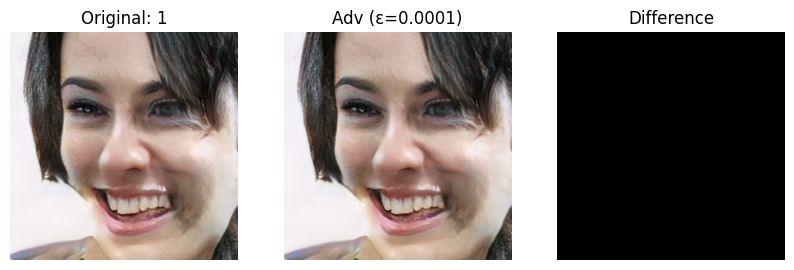

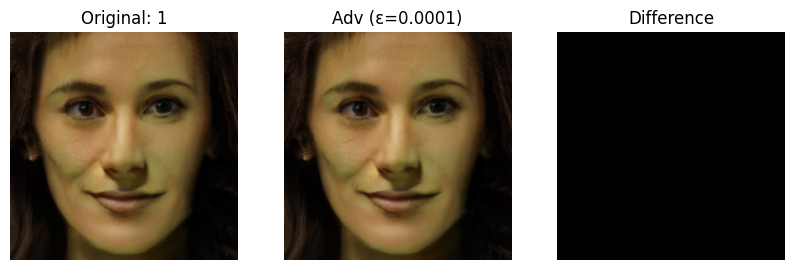

100%|██████████| 63/63 [00:06<00:00,  9.89it/s]



Classification Report on Adversarial Data (epsilon = 0.0001):
              precision    recall  f1-score   support

           0     0.5252    0.3860    0.4450      1000
           1     0.5146    0.6510    0.5748      1000

    accuracy                         0.5185      2000
   macro avg     0.5199    0.5185    0.5099      2000
weighted avg     0.5199    0.5185    0.5099      2000


Confusion Matrix on Adversarial Data:
[[386 614]
 [349 651]]

Evaluating with FGSM (epsilon = 0.001)


  0%|          | 0/63 [00:00<?, ?it/s]

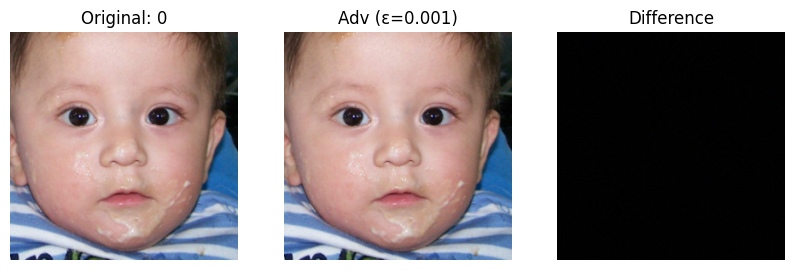

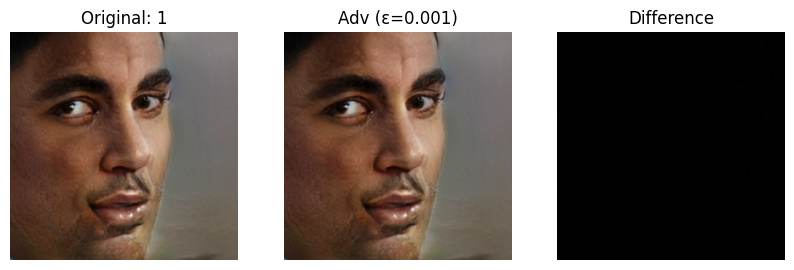

100%|██████████| 63/63 [00:06<00:00,  9.82it/s]



Classification Report on Adversarial Data (epsilon = 0.001):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0884    0.0970    0.0925      1000

    accuracy                         0.0485      2000
   macro avg     0.0442    0.0485    0.0463      2000
weighted avg     0.0442    0.0485    0.0463      2000


Confusion Matrix on Adversarial Data:
[[   0 1000]
 [ 903   97]]

Evaluating with FGSM (epsilon = 0.01)


  0%|          | 0/63 [00:00<?, ?it/s]

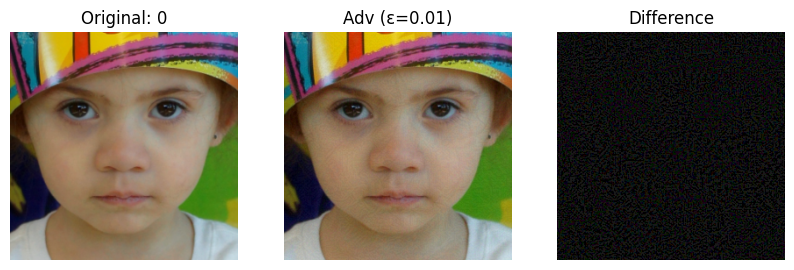

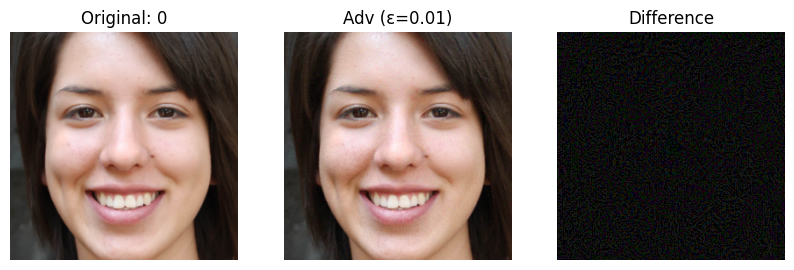

100%|██████████| 63/63 [00:06<00:00,  9.77it/s]



Classification Report on Adversarial Data (epsilon = 0.01):
              precision    recall  f1-score   support

           0     0.0510    0.0520    0.0515      1000
           1     0.0327    0.0320    0.0323      1000

    accuracy                         0.0420      2000
   macro avg     0.0418    0.0420    0.0419      2000
weighted avg     0.0418    0.0420    0.0419      2000


Confusion Matrix on Adversarial Data:
[[ 52 948]
 [968  32]]

Evaluating with FGSM (epsilon = 0.1)


  0%|          | 0/63 [00:00<?, ?it/s]

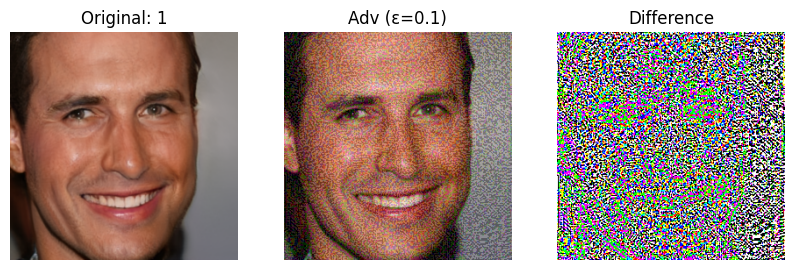

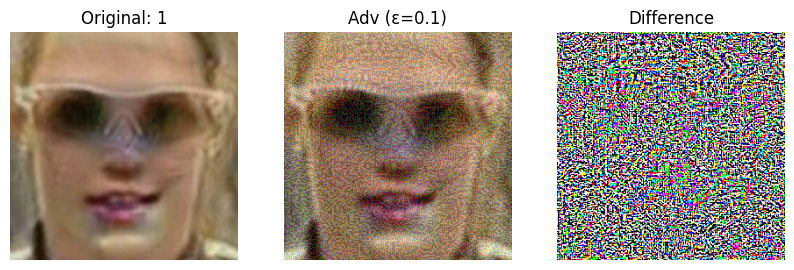

100%|██████████| 63/63 [00:06<00:00,  9.86it/s]



Classification Report on Adversarial Data (epsilon = 0.1):
              precision    recall  f1-score   support

           0     0.5360    0.3200    0.4008      1000
           1     0.5153    0.7230    0.6017      1000

    accuracy                         0.5215      2000
   macro avg     0.5257    0.5215    0.5012      2000
weighted avg     0.5257    0.5215    0.5012      2000


Confusion Matrix on Adversarial Data:
[[320 680]
 [277 723]]


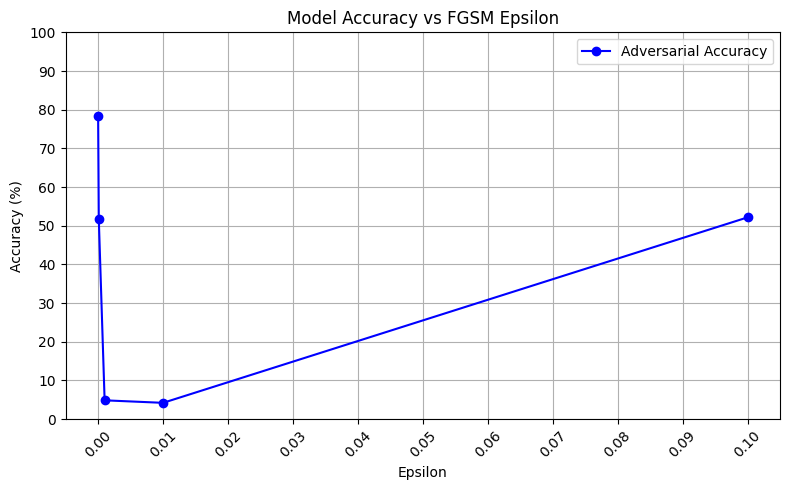

In [28]:
epsilons = [0, 0.0001, 0.001, 0.01, 0.1]
accuracies = []

for eps in epsilons:
    print(f"\nEvaluating with FGSM (epsilon = {eps})")
    acc = evaluate_fgsm(
        model=robust_model,              
        dataloader=test_dataloader,          
        device=device,
        epsilon=eps,
        visualize=True,                 
        num_visualize=2
    )
    accuracies.append(acc)

plot_accuracies(accuracies=accuracies, epsilons = epsilons)